In [ ]:
# KNN 

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

In [14]:
# ---- class_weight comparison: does weighting the minority class reduce false negatives? ----
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, classification_report, recall_score
import pandas as pd
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt

In [8]:
# Rebuild X, y (Amyloid + Total tau, MCI only) — same as cell 45
df = pd.read_csv("data/plasma_lipidomics.csv")

In [9]:
mci = df[df['Diagnostic'] == 'Mild Cognitive Impairment'].copy()
amyloid_median = mci['CSF Amyloid (pg/mL)'].median()
mci['CSF Amyloid (pg/mL)'] = mci['CSF Amyloid (pg/mL)'].fillna(amyloid_median)
tau_median = mci['CSF Total tau (pg/mL)'].median()
mci['CSF Total tau (pg/mL)'] = mci['CSF Total tau (pg/mL)'].fillna(tau_median)

mci['target'] = (mci["Progression to Alzheimer's Disease"] == 'Yes').astype(int)
y = mci['target']
X = mci[['CSF Amyloid (pg/mL)', 'CSF Total tau (pg/mL)']]

print("Class balance (0=No progression, 1=Progressed):")
print(y.value_counts(), "\n")

Class balance (0=No progression, 1=Progressed):
target
1    47
0    42
Name: count, dtype: int64 



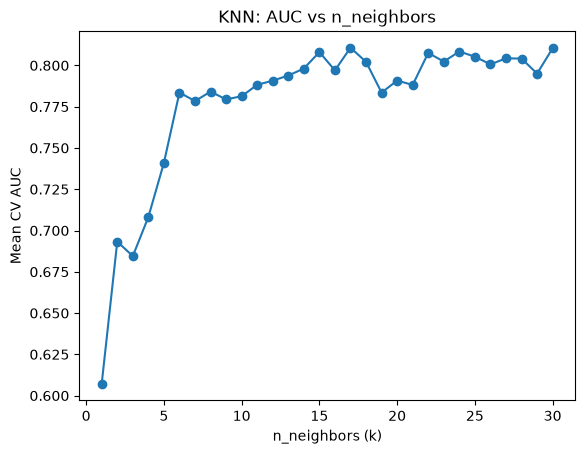

In [16]:

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
k_range = range(1, 31)
knn_scores = []
for k in k_range:
    pipe = Pipeline([('sc', StandardScaler()), ('clf', KNeighborsClassifier(n_neighbors=k))])
    score = cross_val_score(pipe, X, y, cv=cv, scoring='roc_auc')
    knn_scores.append(score.mean())

plt.plot(list(k_range), knn_scores, marker='o')
plt.xlabel('n_neighbors (k)')
plt.ylabel('Mean CV AUC')
plt.title('KNN: AUC vs n_neighbors')
plt.savefig(f"images/uac_n_nei", dpi=300, bbox_inches="tight")
plt.show()

AUC increases sharply up to k≈7, after which additional neighbors yield diminishing and statistically indistinguishable returns; k=7 was selected as the elbow point to balance bias/variance without overfitting to CV noise.